# 03b-03 - From Matches to Tracks

03b-02 ended with one photograph full of features, each with a position, a scale, a direction and 128 numbers that describe the patch around it. A feature on its own places nothing. The second half of the lecture's tie points box is to find the same ground point in the other photographs, and the software did it in three moves. It matched descriptors between two photographs and kept a match only when the nearest neighbour was clearly better than the second nearest, which is Lowe's ratio test. It asked whether the matches of a pair agree on one camera motion, written as the fundamental matrix, and threw out the ones that did not, which is RANSAC. And it joined the surviving pairwise matches across every photograph into tracks, each track one ground point seen in several photographs, which is a union find.

This notebook does all three by hand on the flight's own data. We take the pair of photographs the kit pins, match their descriptors ourselves and count what the ratio test keeps, fit the fundamental matrix with the eight-point algorithm inside RANSAC and count what the geometry keeps, and draw the epipolar lines that the dense matching of 03b-05 will search along. Then we step back to every pair of the flight as the software recorded it, and forward to the eight-photograph neighbourhood around our photograph, whose matches we join into tracks and set, length by length, beside the tracks the software built. Everything the adjustment of 03b-04 stands on is counted here.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## The pair

The kit pins one pair of photographs for every flight by a rule that `flight.json` records and the cell prints. photo_a is the photograph that sees the pinned window best, and photo_b is its strongest match partner beyond a minimum baseline, because two photographs taken from nearly the same spot match beautifully and measure nothing. The distance between the two camera centres is the baseline, and it decides everything about the pair, how far a point on the ground shifts between the two pictures and along which direction. The software's reconstruction holds both cameras, so we recover the centres from the rotation and translation it wrote, minus R transposed times t, and read the baseline off them. Then we express the baseline in photo_a's own axes, where u runs across the picture and v down it. That direction is the direction of the epipolar lines, which we draw further down:

the pair             DJI_0823.JPG and DJI_0822.JPG, chosen as photo_a and its strongest match partner at a baseline of at least 8.0 m
the samples          2000 by 1500 pixels, from frames of 4000 by 3000
camera centres       a at 138.6, -23.2, -14.5 m and b at 127.6, -25.3, -14.8 m, in the map frame minus the offset
baseline             11.16 m   reference 11.16
base over height     0.164, the camera standing 68.2 m over the window's surface
epipolar direction   -86.3 degrees from the u axis of photo_a, positive toward v   reference -86.3


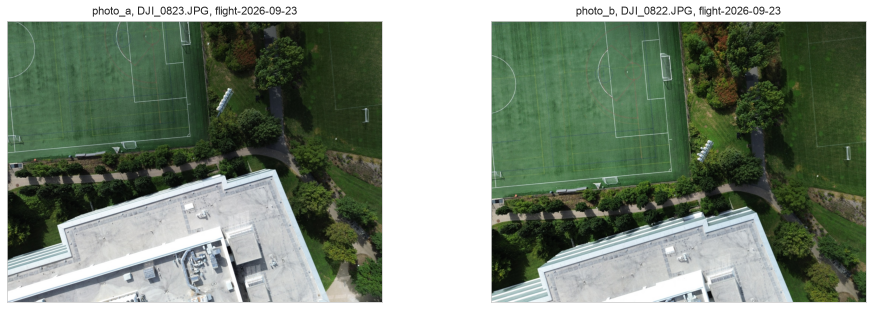

In [2]:
block = np.load("data/block.npz")
names = [str(n) for n in block["names"]]
camera = json.loads(str(block["camera"]))
photo_a = np.asarray(Image.open("data/photo_a.jpg")); photo_b = np.asarray(Image.open("data/photo_b.jpg"))
sample_h, sample_w = photo_a.shape[:2]                                     # the kit's sample size, always read from the image itself
name_a, name_b = choices["pair"]["a"], choices["pair"]["b"]
index_a, index_b = names.index(name_a), names.index(name_b)

def rodrigues(axis_angle):
    '''The rotation matrix of an axis angle vector, the form the software writes its rotations in.'''
    axis_angle = np.asarray(axis_angle, dtype=float); theta = float(np.linalg.norm(axis_angle))
    if theta < 1e-12:
        return np.eye(3)
    k = axis_angle / theta; K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K

def camera_centre(rotation, translation):
    '''Where the lens was, minus R transposed times t.'''
    return -rodrigues(rotation).T @ np.asarray(translation, dtype=float)

centre_a = camera_centre(block["rotation_map"][index_a], block["translation_map"][index_a])
centre_b = camera_centre(block["rotation_map"][index_b], block["translation_map"][index_b])
baseline = centre_b - centre_a
in_camera_a = rodrigues(block["rotation_map"][index_a]) @ baseline          # the baseline in photo_a's own axes, x across, y down, z forward
direction_deg = math.degrees(math.atan2(in_camera_a[1], in_camera_a[0]))
height_over_window = centre_a[2] - choices["window"]["surface_median_m"]
print(f"the pair             {name_a} and {name_b}, chosen as {choices['pair']['rule']}")
print(f"the samples          {sample_w} by {sample_h} pixels, from frames of {camera['width']} by {camera['height']}")
print(f"camera centres       a at {centre_a[0]:.1f}, {centre_a[1]:.1f}, {centre_a[2]:.1f} m and b at {centre_b[0]:.1f}, {centre_b[1]:.1f}, {centre_b[2]:.1f} m, in the map frame minus the offset")
print(f"baseline             {np.linalg.norm(baseline):.2f} m   reference {reference['pair']['baseline_m']}")
print(f"base over height     {np.linalg.norm(baseline) / height_over_window:.3f}, the camera standing {height_over_window:.1f} m over the window's surface")
print(f"epipolar direction   {direction_deg:.1f} degrees from the u axis of photo_a, positive toward v   reference {reference['pair']['epipolar_direction_deg_from_u']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, image, name, letter in zip(axes, (photo_a, photo_b), (name_a, name_b), "ab"):
    ax.imshow(image); ax.set_title(f"photo_{letter}, {name}, {flight['label']}", fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Read the baseline first and hold it against the height on the line below it. Their ratio, base over height, is what the photogrammetry texts call the base-height ratio, and it sets the parallax of the pair. A small ratio means the two pictures look nearly alike and heights come out poorly, a large one means strong parallax and fewer features in common, and aerial blocks live at a few tenths. Then read the direction. The baseline expressed in photo_a's axes has almost no forward component, since the two cameras flew at one height, so it lies in the picture plane, and the angle printed is the angle at which every epipolar line will cross photo_b. A level nadir pair has lines that run along the direction the aircraft moved between the two exposures, tilted by however much the camera's heading differed from that direction.

Look at the two photographs with that in mind. The same paths, crowns and roofs appear in both, shifted mostly along that one direction, and everything that follows is a machine for finding those shifts one feature at a time.

## Matching by descriptor, with the ratio test

Every feature of photo_a carries 128 numbers, and so does every feature of photo_b. The plain idea is to pair each feature of a with the feature of b whose descriptor is nearest in Euclidean distance, and the plain idea fails for a reason a mown lawn makes obvious. A feature with no true partner still has a nearest neighbour, just a meaningless one. Lowe's ratio test repairs it. For each feature we find the two nearest descriptors in the other photograph and keep the match only if the nearest is closer than a fixed fraction of the second nearest, since a real match beats every impostor clearly while a false one is one impostor among many. The squared distance between two descriptors is the sum of their squared norms less twice their dot product, so one matrix product gives every distance at once, a thousand rows at a time, and `argpartition` picks the two smallest per row without sorting the rest. The software used the same test at 0.8, and so do we:

DJI_0823.JPG has 3664 features and DJI_0822.JPG has 4418, each described by 128 numbers
ratio test at 0.8    2844 candidates from the 3664 features of photo_a, 77.6%   reference 2844


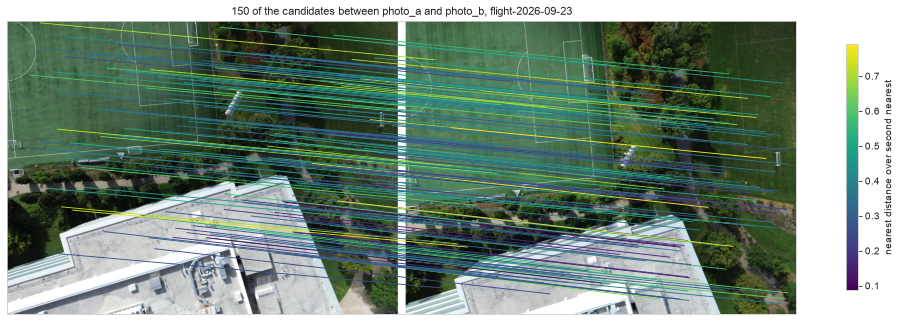

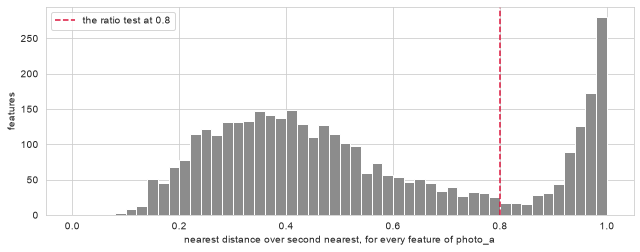

In [3]:
features = np.load("data/features_pair.npz")
points_a, points_b = features["points_a"], features["points_b"]
descriptors_a, descriptors_b = features["descriptors_a"], features["descriptors_b"]
print(f"{features['name_a']} has {len(points_a)} features and {features['name_b']} has {len(points_b)}, each described by {descriptors_a.shape[1]} numbers")

def feature_pixels(points, width, height):
    '''The feature file's normalised x and y as pixels of an image of the given size.'''
    size = max(width, height)
    return points[:, 0] * size + width / 2.0 - 0.5, points[:, 1] * size + height / 2.0 - 0.5

def two_nearest(descriptors_from, descriptors_to, chunk=1000):
    '''For every descriptor of one photograph, its nearest descriptor in the other and the ratio of the nearest distance to the second nearest.'''
    a = np.asarray(descriptors_from, dtype=np.float32); b = np.asarray(descriptors_to, dtype=np.float32)
    bb = (b * b).sum(axis=1)
    nearest, ratios = [], []
    for start in range(0, len(a), chunk):                                  # a thousand rows at a time keeps the distance matrix small
        part = a[start:start + chunk]
        squared = (part * part).sum(axis=1)[:, None] + bb[None, :] - 2.0 * part @ b.T     # every squared distance of the chunk at once
        two = np.argpartition(squared, 1, axis=1)[:, :2]                   # the two smallest per row, in no particular order
        distances = np.take_along_axis(squared, two, axis=1)
        first = np.argmin(distances, axis=1); rows = np.arange(len(part))
        best, second = distances[rows, first], distances[rows, 1 - first]
        nearest.append(two[rows, first]); ratios.append(np.sqrt(np.maximum(best, 0) / np.maximum(second, 1e-12)))
    return np.concatenate(nearest), np.concatenate(ratios)

RATIO = 0.8
nearest, ratios = two_nearest(descriptors_a, descriptors_b)
passed = ratios < RATIO
candidates_a, candidates_b = np.nonzero(passed)[0], nearest[passed]
print(f"ratio test at {RATIO}    {passed.sum()} candidates from the {len(points_a)} features of photo_a, {passed.mean():.1%}   reference {reference['pair']['ratio_0_8']['candidates']}")

pixels_a = np.column_stack(feature_pixels(points_a[candidates_a], sample_w, sample_h))
pixels_b = np.column_stack(feature_pixels(points_b[candidates_b], sample_w, sample_h))
gap = 40                                                                   # the two samples side by side on one canvas, a white strip between them
canvas = np.full((sample_h, 2 * sample_w + gap, 3), 255, dtype=np.uint8)
canvas[:, :sample_w] = photo_a; canvas[:, sample_w + gap:] = photo_b
rng = np.random.default_rng(20260930)
shown = rng.choice(len(candidates_a), min(150, len(candidates_a)), replace=False)
segments = [[(pixels_a[i, 0], pixels_a[i, 1]), (pixels_b[i, 0] + sample_w + gap, pixels_b[i, 1])] for i in shown]

fig, ax = plt.subplots(figsize=(14, 4.6))
ax.imshow(canvas)
lines = LineCollection(segments, array=ratios[candidates_a][shown], cmap="viridis", linewidths=0.9)
ax.add_collection(lines); fig.colorbar(lines, ax=ax, shrink=0.8, label="nearest distance over second nearest")
ax.set_title(f"{len(shown)} of the candidates between photo_a and photo_b, {flight['label']}", fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(ratios, bins=50, range=(0, 1), color="0.55")
ax.axvline(RATIO, color="crimson", linestyle="--", label=f"the ratio test at {RATIO}")
ax.set_xlabel("nearest distance over second nearest, for every feature of photo_a"); ax.set_ylabel("features"); ax.legend(loc="upper left")
fig.tight_layout()

The first line counts the features on each side and the second says how many of photo_a's features found a partner that passed the test, with the share. Read the share as the fraction of features with a convincing partner, not as the fraction with a correct one, since a candidate is a claim and the next section tests it. The picture shows a subsample of the claims. Most lines run in one bundle, shifted by about the same amount in about the same direction, which is the parallax of the pair; look for the few that leave the bundle at an angle of their own, which no camera motion could produce, since those passed the ratio test and are still wrong, and the colour scale lets you check whether the odd lines are also the doubtful ones. The histogram is the argument for the test, and it is the picture Lowe drew in his paper. Look for two humps, one low on the axis where a partner stands clear of every other, and one against the right edge where the two nearest are equally far and the feature has no partner at all, which is what a lawn does to a descriptor. The threshold should fall in the trough between them, and 0.8 is where Lowe put it after counting how many correct and incorrect matches each setting kept. A fixed distance could not do this, because a descriptor on a strong roof corner and one on weak lawn texture live at different distances from everything, while the ratio asks the same question of both, whether the best partner stands clear of the second best. Where the threshold cuts is a trade between missing true matches and admitting false ones, and the your-turn at the end moves it.

## The geometric check

A candidate is a claim about the pictures; the check is a claim about the world. Two photographs of one rigid scene are related by their epipolar geometry. For any point x in photo_a, its partner x' in photo_b lies on a line, and the fundamental matrix F holds that relation as x' transposed F x equal to zero for every true correspondence. F has nine entries and one free scale, and its determinant is zero, so it has seven degrees of freedom. Each correspondence gives one linear equation in the nine entries, and eight of them determine F up to scale, which is the eight-point algorithm. Two details make it work in practice. Hartley's normalisation moves each point set to its centroid and scales it so the average distance from the centre is the square root of two, without which pixel coordinates in the thousands swamp the ones in the last column and the linear system is hopelessly conditioned. And the rank two constraint is imposed afterwards by zeroing the smallest singular value.

The candidates are not all true, and even a few wrong ones would bend a least squares fit of F arbitrarily, because a wrong match is not a small error but a gross one. RANSAC, random sample consensus, is the answer Fischler and Bolles gave in 1981. Draw eight candidates at random, fit F, count how many of all the candidates agree with it to within a tolerance, repeat many times, keep the F with the most agreement, and refit it on its inliers. The tolerance is the Sampson distance, a first order measure of how far a correspondence sits from satisfying the epipolar constraint, in pixels of the sample. We use one pixel, two thousand draws and a fixed seed, so that the count is repeatable:

inliers               2614 of 2844 candidates, 91.9%   reference 2614, 91.9%
thrown out            230 candidates that passed the ratio test and failed the geometry at 1.0 px
the software's count  2584 robust matches for this pair in pairs.csv   reference 2584


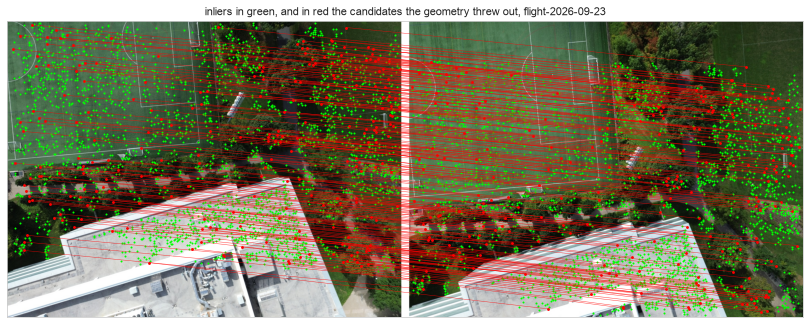

In [4]:
def normalise_points(points):
    '''Hartley's normalisation: the points centred and scaled so that their mean distance from the centre is the square root of two.'''
    centre = points.mean(axis=0); scale = math.sqrt(2.0) / np.sqrt(((points - centre) ** 2).sum(axis=1)).mean()
    T = np.array([[scale, 0.0, -scale * centre[0]], [0.0, scale, -scale * centre[1]], [0.0, 0.0, 1.0]])
    return (points - centre) * scale, T

def eight_point(pa, pb):
    '''The fundamental matrix from eight or more correspondences: one linear equation per pair, the SVD's last vector, the rank two constraint, the normalisation undone.'''
    na, Ta = normalise_points(pa); nb, Tb = normalise_points(pb)
    A = np.column_stack([nb[:, 0] * na[:, 0], nb[:, 0] * na[:, 1], nb[:, 0], nb[:, 1] * na[:, 0], nb[:, 1] * na[:, 1], nb[:, 1], na[:, 0], na[:, 1], np.ones(len(na))])
    _, _, vt = np.linalg.svd(A)
    F = vt[-1].reshape(3, 3)
    u, s, vt = np.linalg.svd(F); s[2] = 0.0                                   # a fundamental matrix has rank two
    F = u @ np.diag(s) @ vt
    F = Tb.T @ F @ Ta
    return F / F[2, 2] if abs(F[2, 2]) > 1e-12 else F

def sampson_distance(F, pa, pb):
    '''How far each correspondence is from satisfying the epipolar constraint, to first order, in pixels.'''
    ha = np.column_stack([pa, np.ones(len(pa))]); hb = np.column_stack([pb, np.ones(len(pb))])
    Fa = ha @ F.T; Ftb = hb @ F
    numerator = (hb * Fa).sum(axis=1) ** 2
    denominator = Fa[:, 0] ** 2 + Fa[:, 1] ** 2 + Ftb[:, 0] ** 2 + Ftb[:, 1] ** 2
    return np.sqrt(numerator / np.maximum(denominator, 1e-12))

def fundamental_ransac(pa, pb, iterations=2000, threshold_px=1.0, seed=0):
    '''RANSAC over eight-point samples: the F with the most correspondences within the threshold, refitted on its inliers.'''
    rng = np.random.default_rng(seed)
    pa = np.asarray(pa, dtype=float); pb = np.asarray(pb, dtype=float)
    best_mask, best_count = None, -1
    for _ in range(iterations):
        pick = rng.choice(len(pa), 8, replace=False)
        try:
            F = eight_point(pa[pick], pb[pick])
        except np.linalg.LinAlgError:
            continue
        agree = sampson_distance(F, pa, pb) < threshold_px
        if agree.sum() > best_count:
            best_count, best_mask = int(agree.sum()), agree
    F = eight_point(pa[best_mask], pb[best_mask])
    return F, sampson_distance(F, pa, pb) < threshold_px

F, inliers = fundamental_ransac(pixels_a, pixels_b, iterations=2000, threshold_px=1.0, seed=0)
pairs = pd.read_csv("data/pairs.csv")
this_pair = pairs[pairs["image_a"].isin([name_a, name_b]) & pairs["image_b"].isin([name_a, name_b])]
print(f"inliers               {inliers.sum()} of {len(inliers)} candidates, {inliers.mean():.1%}   reference {reference['pair']['ratio_0_8']['inliers']}, {reference['pair']['ratio_0_8']['inlier_share']:.1%}")
print(f"thrown out            {(~inliers).sum()} candidates that passed the ratio test and failed the geometry at {reference['pair']['sampson_threshold_px']} px")
print(f"the software's count  {int(this_pair['matches'].iloc[0])} robust matches for this pair in pairs.csv   reference {reference['pair']['software_matches']}")

fig, ax = plt.subplots(figsize=(14, 4.6))
ax.imshow(canvas)
for shift, pixels in ((0, pixels_a), (sample_w + gap, pixels_b)):
    ax.scatter(pixels[inliers, 0] + shift, pixels[inliers, 1], s=4, color="lime", linewidths=0)
    ax.scatter(pixels[~inliers, 0] + shift, pixels[~inliers, 1], s=8, color="red", linewidths=0)
rejected = [[(pixels_a[i, 0], pixels_a[i, 1]), (pixels_b[i, 0] + sample_w + gap, pixels_b[i, 1])] for i in np.nonzero(~inliers)[0]]
ax.add_collection(LineCollection(rejected, colors="red", linewidths=0.5, alpha=0.7))
ax.set_title(f"inliers in green, and in red the candidates the geometry threw out, {flight['label']}", fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The first line is the count that matters, and the third is the software's own for the same pair. Read the gap between the candidates and the inliers as what the geometry threw out, and read the share as the ratio test's honesty; a high share says the descriptors rarely lied, a low one would say the scene repeats itself. The software's count is close to ours and not equal to it, and it should not be equal, since the software ran its own ratio test, checked each match in both directions and used its own geometric tolerance. Where two honest procedures differ by a few percent, neither is the truth. In the picture the green points are the flow of the pair and the red lines are the claims that did not fit; look at what they join. Repeated texture is where a descriptor lies most easily, one piece of lawn matched to another, one crown to another, one white line of a court to the next, and the geometry catches it because no single camera motion can move a point that way.

F is more than a filter. It draws the line on which a partner must lie. For a point x in photo_a, l = F x is a line in photo_b, written as three numbers a, b, c with a u + b v + c = 0, and the matched point sits on it to within the tolerance. We pick three inliers by a rule that works on any flight, the inlier nearest the footpath junction at the window's centre, which we find by projecting the window's centre at its surface height into photo_a with the software's pose and camera, and the inliers nearest the upper left and the lower right quarter points of the frame, and we draw their lines across photo_b:

the footpath junction at the window's centre   at  1493,   849 in photo_a; its line in photo_b runs at -88.1 degrees, its partner sits 0.17 px from the line
the upper left quarter of the frame            at   514,   377 in photo_a; its line in photo_b runs at -83.8 degrees, its partner sits 0.99 px from the line
the lower right quarter of the frame           at  1501,  1121 in photo_a; its line in photo_b runs at -88.2 degrees, its partner sits 0.25 px from the line


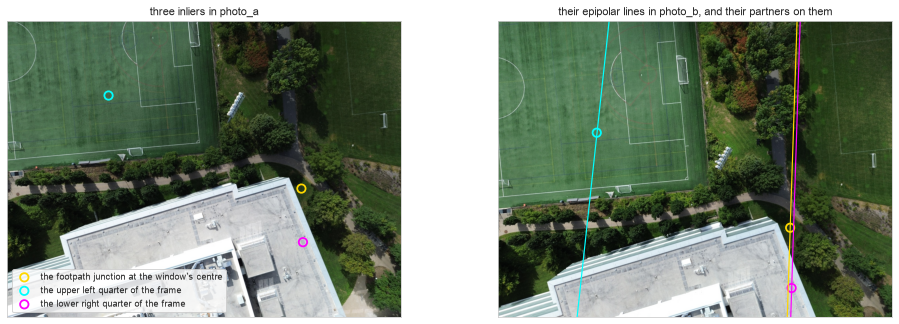

In [5]:
def project_brown(points_xyz, rotation, translation, camera, width, height):
    '''The collinearity equations as the software writes them: a world point into the camera's axes, the perspective division, the Brown distortion, then pixels of an image of the given size.'''
    p = np.atleast_2d(np.asarray(points_xyz, dtype=float)) @ rodrigues(rotation).T + np.asarray(translation, dtype=float)
    x, y = p[:, 0] / p[:, 2], p[:, 1] / p[:, 2]
    r2 = x * x + y * y
    radial = 1.0 + camera["k1"] * r2 + camera["k2"] * r2 ** 2 + camera["k3"] * r2 ** 3
    xd = x * radial + 2.0 * camera["p1"] * x * y + camera["p2"] * (r2 + 2.0 * x * x)
    yd = y * radial + 2.0 * camera["p2"] * x * y + camera["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)
    return (camera["focal_x"] * xd + camera["c_x"]) * size + width / 2.0 - 0.5, (camera["focal_y"] * yd + camera["c_y"]) * size + height / 2.0 - 0.5

junction = [choices["window"]["centre_local"][0], choices["window"]["centre_local"][1], choices["window"]["surface_median_m"]]
ju, jv = project_brown(junction, block["rotation_map"][index_a], block["translation_map"][index_a], camera, sample_w, sample_h)
targets = {"the footpath junction at the window's centre": (ju[0], jv[0]), "the upper left quarter of the frame": (sample_w / 4, sample_h / 4), "the lower right quarter of the frame": (3 * sample_w / 4, 3 * sample_h / 4)}
inlier_rows = np.nonzero(inliers)[0]
chosen = {label: inlier_rows[np.argmin(np.hypot(pixels_a[inlier_rows, 0] - tu, pixels_a[inlier_rows, 1] - tv))] for label, (tu, tv) in targets.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].imshow(photo_a); axes[1].imshow(photo_b)
u_line = np.array([0.0, sample_w])
for colour, (label, i) in zip(("gold", "cyan", "magenta"), chosen.items()):
    a, b, c = F @ np.array([pixels_a[i, 0], pixels_a[i, 1], 1.0])            # the epipolar line a u + b v + c = 0 in photo_b
    line_deg = (math.degrees(math.atan2(-a, b)) + 90) % 180 - 90              # its direction, folded onto the same range as the baseline's
    axes[0].scatter(pixels_a[i, 0], pixels_a[i, 1], s=70, facecolor="none", edgecolor=colour, linewidth=1.8, label=label)
    axes[1].plot(u_line, -(a * u_line + c) / b, color=colour, linewidth=1.2)
    axes[1].scatter(pixels_b[i, 0], pixels_b[i, 1], s=70, facecolor="none", edgecolor=colour, linewidth=1.8)
    print(f"{label:46} at {pixels_a[i, 0]:5.0f}, {pixels_a[i, 1]:5.0f} in photo_a; its line in photo_b runs at {line_deg:5.1f} degrees, its partner sits {sampson_distance(F, pixels_a[[i]], pixels_b[[i]])[0]:.2f} px from the line")
axes[0].set_title("three inliers in photo_a", fontsize=11); axes[1].set_title("their epipolar lines in photo_b, and their partners on them", fontsize=11)
axes[0].legend(loc="lower left", fontsize=9)
for ax in axes:
    ax.set_xlim(0, sample_w); ax.set_ylim(sample_h, 0); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Three points, three lines, and the partner of each point sits on its line within the distance the last number states. Compare the angle of the lines with the epipolar direction printed at the start of the notebook; they agree, because each line is the image in photo_b of the ray through photo_a's point, and all those rays pass through photo_a's camera centre, whose image in photo_b is the epipole. For a level pair the epipole lies far outside the frame, so the lines are very nearly parallel, and had the second camera stood on the first one's optical axis the lines would instead radiate from the picture's centre. This is the constraint the dense matching of 03b-05 lives on. For every pixel of photo_a, the search for its partner is not over the whole of photo_b but along one line in it, and the position along the line is the depth.

## Every pair of the flight

We matched one pair. The software matched hundreds, and `pairs.csv` records every pair it considered, whether it was a candidate, how many robust matches survived and how many tracks the two photographs ended up sharing. The software did not try every possible pair, which for a flight of this size would be thousands; it chose candidates by the receiver's positions, the nearest photographs by distance, and matched those. Here is what it tried, what it matched, and how the matched pairs sit on the map between the receiver's positions, each line the width of its match count:

possible pairs        3570 among the 85 photographs
candidate pairs       762 the software tried   reference 762
matched pairs         672 where matches survived, 1120 matches per pair on average   reference 672
view graph edges      1884 pairs that share at least one track   reference 1884
our pair              2584 robust matches, 2669 shared tracks
03b-01's footprints   of the matched pairs, 659 were predicted at twenty percent overlap or more, and 0 were never predicted at all


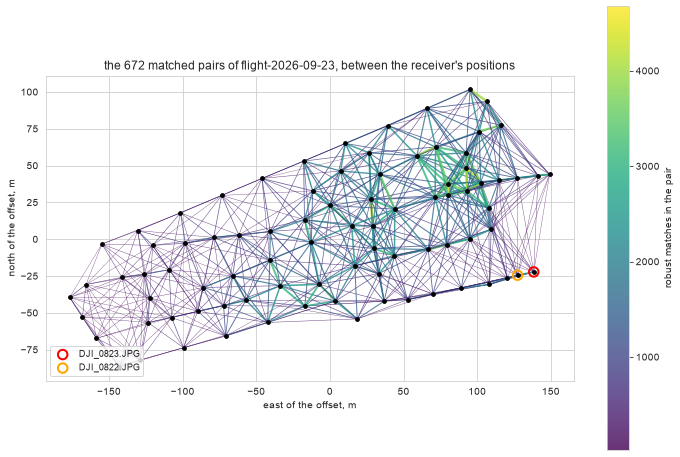

In [6]:
photos = pd.read_csv("data/photos.csv")
position = {row.file: (row.easting - choices["offset"][0], row.northing - choices["offset"][1]) for row in photos.itertuples()}
matched = pairs[pairs["matches"] > 0]
unique_matched = len({frozenset((a, b)) for a, b in zip(matched["image_a"], matched["image_b"])})     # counted once whichever way a pair is written
possible = len(photos) * (len(photos) - 1) // 2
print(f"possible pairs        {possible} among the {len(photos)} photographs")
print(f"candidate pairs       {int(pairs['candidate'].sum())} the software tried   reference {reference['overlap']['candidate_pairs']}")
print(f"matched pairs         {unique_matched} where matches survived, {matched['matches'].mean():.0f} matches per pair on average   reference {reference['overlap']['matched_pairs']}")
print(f"view graph edges      {int((pairs['common_tracks'] > 0).sum())} pairs that share at least one track   reference {reference['overlap']['view_graph_edges']}")
print(f"our pair              {int(this_pair['matches'].iloc[0])} robust matches, {int(this_pair['common_tracks'].iloc[0])} shared tracks")
print(f"03b-01's footprints   of the matched pairs, {reference['overlap']['matched_among_predicted_20']} were predicted at twenty percent overlap or more, and {reference['overlap']['matched_not_predicted']} were never predicted at all")

fig, ax = plt.subplots(figsize=(10, 8))
segments = [[position[a], position[b]] for a, b in zip(matched["image_a"], matched["image_b"])]
lines = LineCollection(segments, array=matched["matches"].values, cmap="viridis", linewidths=0.3 + 2.5 * matched["matches"].values / matched["matches"].max(), alpha=0.8)
ax.add_collection(lines); fig.colorbar(lines, ax=ax, shrink=0.8, label="robust matches in the pair")
xs, ys = zip(*position.values())
ax.scatter(xs, ys, s=14, color="black", zorder=3)
for name, colour in ((name_a, "red"), (name_b, "orange")):
    ax.scatter(*position[name], s=90, facecolor="none", edgecolor=colour, linewidth=2, zorder=4, label=name)
ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=9)
ax.set_xlabel("east of the offset, m"); ax.set_ylabel("north of the offset, m")
ax.set_title(f"the {unique_matched} matched pairs of {flight['label']}, between the receiver's positions", fontsize=12)
fig.tight_layout()

Read the counts as a funnel that widens again at the end. The possible pairs are all of them. The candidates are the ones the software chose to try, by the receiver's positions rather than by our footprints. The matched pairs are the candidates where matches survived the ratio test and the geometry, and the difference between the two is the candidates where nothing did. The last count is larger than the candidates, which looks wrong until you remember what a track is. Two photographs share a track whenever a ground point was matched from each of them to some third photograph, so tracks tie together pairs the software never matched directly, and that is exactly what the next section builds. The footprint line recalls 03b-01. Most matched pairs were ones the footprints predicted at twenty percent or more, and the few they never predicted at all are pairs whose overlap our simple rectangles missed. On the map the thick lines join neighbours along the flight's path and the thin ones join photographs across it, and the pattern of the flight is legible in the pattern of the pairs, because the software's candidates were chosen by position.

## From pairs to tracks, by union find

A match joins two features. A track joins all the features, across all the photographs, that are one and the same ground point, and it is what the adjustment of 03b-04 will triangulate. Building tracks from pairwise matches is a graph problem. Every feature of every photograph is a node, every match is an edge, and a track is a connected component. The union find structure solves it in a few lines. Each node points to a parent, a root stands for a component, `find` follows the pointers to the root and shortens the path on the way, and every match unites the two roots. The kit carries the software's robust matches within the eight-photograph neighbourhood around photo_a, and we build the tracks from them, then set them beside the tracks the software built and kept, restricted to the same eight photographs, and beside the lengths of every track of the flight:

27 pairs with matches among the 8 photographs of the neighbourhood, 30057 matches in all   reference 27 pairs, 30057 matches
tracks by union find             10482, mean length 2.84   reference 10482, 2.84
  longer than the group          7 of them hold two features of one photograph, which no ground point can
the software's, same 8 photographs  10573 of its points are seen by at least two of them   reference 10573
the whole flight                 81028 tracks, mean length 4.57, the longest 25   reference 81028, 4.57, 25
the report's mean length         4.58, over the tracks that became points   reference 4.58

  length   by hand  reference  software  reference    flight  reference
       2      5847       5847      5876       5876     33022      33022
       3      2478       2478      2552       2552     13397      13397
       4      1051       1051      1047       1047      8622       8622
       5       592        592       589        589      5478       5478
       6       246   

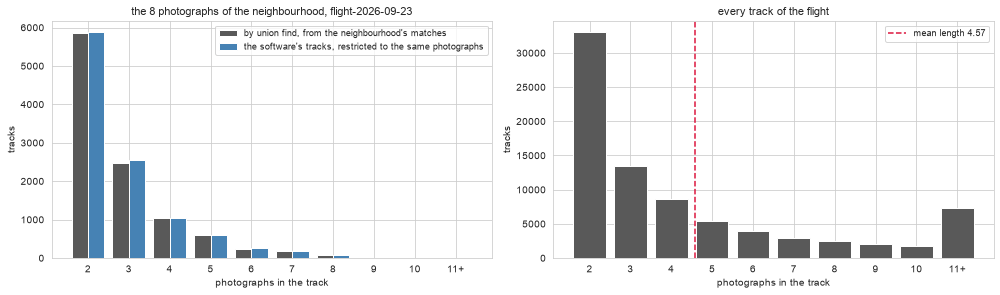

In [7]:
group = list(choices["group"]); group_index = [names.index(n) for n in group]
matches_group = np.load("data/matches_group.npz")
group_matches = {tuple(key.split("__")): matches_group[key] for key in matches_group.files if "__" in key}
print(f"{len(group_matches)} pairs with matches among the {len(group)} photographs of the neighbourhood, {sum(len(v) for v in group_matches.values())} matches in all   reference {reference['tracks']['group']['pairs_with_matches']} pairs, {reference['tracks']['group']['matches']} matches")

def union_find_tracks(matches):
    '''Pairwise matches into tracks: every (photograph, feature) is a node, every match an edge, a track a connected component. Returns the track of every node and the length of every track.'''
    parent = {}

    def find(node):
        while parent.setdefault(node, node) != node:
            parent[node] = parent[parent[node]]; node = parent[node]        # halve the path on the way up
        return node

    for (image_a, image_b), feature_pairs in matches.items():
        for i, j in feature_pairs:
            root_a, root_b = find((image_a, int(i))), find((image_b, int(j)))
            if root_a != root_b:
                parent[root_a] = root_b                                     # unite the two components
    roots, track_of = {}, {}
    for node in list(parent):
        track_of[node] = roots.setdefault(find(node), len(roots))
    lengths = np.bincount(np.fromiter(track_of.values(), dtype=np.int64), minlength=len(roots))
    return track_of, lengths

def length_histogram(lengths):
    '''Tracks of two to ten photographs, and everything longer in one bin.'''
    counts = {str(k): int((lengths == k).sum()) for k in range(2, 11)}; counts["11+"] = int((lengths >= 11).sum())
    return counts

track_of, by_hand = union_find_tracks(group_matches)
by_hand = by_hand[by_hand >= 2]
tracks = np.load("data/tracks.npz")
in_group = np.isin(tracks["shot"], group_index)
_, software = np.unique(tracks["point"][in_group], return_counts=True)
software = software[software >= 2]
whole_flight = tracks["track_lengths"].astype(int)
report = json.load(open("data/report.json"))
print(f"tracks by union find             {len(by_hand)}, mean length {by_hand.mean():.2f}   reference {reference['tracks']['group']['union_find_tracks']}, {reference['tracks']['group']['mean_length']}")
print(f"  longer than the group          {(by_hand > len(group)).sum()} of them hold two features of one photograph, which no ground point can")
print(f"the software's, same {len(group)} photographs  {len(software)} of its points are seen by at least two of them   reference {reference['tracks']['group']['software_tracks_within_group']}")
print(f"the whole flight                 {len(whole_flight)} tracks, mean length {whole_flight.mean():.2f}, the longest {whole_flight.max()}   reference {reference['tracks']['tracks']}, {reference['tracks']['mean_length']}, {reference['tracks']['max_length']}")
print(f"the report's mean length         {report['stats']['reconstruction_statistics']['average_track_length']:.2f}, over the tracks that became points   reference {reference['tracks']['report_average_track_length']:.2f}")
print()
print(f"{'length':>8} {'by hand':>9} {'reference':>10} {'software':>9} {'reference':>10} {'flight':>9} {'reference':>10}")
h_hand, h_soft, h_all = length_histogram(by_hand), length_histogram(software), length_histogram(whole_flight)
for k in h_hand:
    print(f"{k:>8} {h_hand[k]:>9} {reference['tracks']['group']['histogram'][k]:>10} {h_soft[k]:>9} {reference['tracks']['group']['software_histogram'][k]:>10} {h_all[k]:>9} {reference['tracks']['histogram'][k]:>10}")

bins = list(h_hand); x = np.arange(len(bins))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(x - 0.2, [h_hand[k] for k in bins], width=0.4, color="0.35", label="by union find, from the neighbourhood's matches")
axes[0].bar(x + 0.2, [h_soft[k] for k in bins], width=0.4, color="steelblue", label="the software's tracks, restricted to the same photographs")
axes[0].set_title(f"the {len(group)} photographs of the neighbourhood, {flight['label']}", fontsize=11)
axes[1].bar(x, [h_all[k] for k in bins], color="0.35")
axes[1].axvline(whole_flight.mean() - 2, color="crimson", linestyle="--", label=f"mean length {whole_flight.mean():.2f}")
axes[1].set_title("every track of the flight", fontsize=11)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(bins); ax.set_xlabel("photographs in the track"); ax.set_ylabel("tracks"); ax.legend(fontsize=9)
fig.tight_layout()

Three counts of tracks, and they should be close without being equal. Ours come from the neighbourhood's matches alone. The software's tracks were built from every match of the flight and then survived the reconstruction, so a track of ours may be two of the software's joined by a chain through a photograph outside the neighbourhood, or may have no software counterpart at all because it was never triangulated. Read the table row by row; the columns agree closely at the short lengths and diverge at the long ones, and the second line of the printout names the honest error in ours. A track that spans more photographs than the neighbourhood has must hold two features of one photograph, which a single ground point cannot, so somewhere a wrong match glued two tracks together. The software throws such a track away whole, which is why its histogram ends where the neighbourhood ends. The right-hand histogram is the whole flight's, and its shape is the shape of the flight. Look at which length is the most numerous and how fast the counts fall, since that says in how many photographs a typical ground point was found and matched. The mean is printed beside the software's report, and they differ a little; the report averages over the tracks that became points, while the file's lengths include the tracks that never did, so if the report's mean is the higher one, the tracks that failed were the short ones.

A track is easiest to believe when you see it. The cell below finds the longest track of the flight, the point with the most observations, and lists the photographs that saw it; the kit carries only three of the flight's photographs, so it also finds the longest track that all three of them see and shows that one as three crops around the feature the software matched:

the longest track of the flight is point 772, seen in 25 photographs: DJI_0799.JPG, DJI_0806.JPG, DJI_0807.JPG, DJI_0864.JPG, DJI_0865.JPG, DJI_0867.JPG, DJI_0903.JPG, DJI_0904.JPG, DJI_0906.JPG, DJI_0907.JPG, DJI_0909.JPG, DJI_0921.JPG, DJI_0925.JPG, DJI_0927.JPG, DJI_0929.JPG, DJI_0931.JPG, DJI_0933.JPG, DJI_0936.JPG, DJI_0962.JPG, DJI_0963.JPG, DJI_0964.JPG, DJI_0965.JPG, DJI_0966.JPG, DJI_0074.JPG, DJI_0076.JPG
of the kit's three photographs it is in none
the longest track all three kit photographs see is point 4897, in 24 photographs of the flight


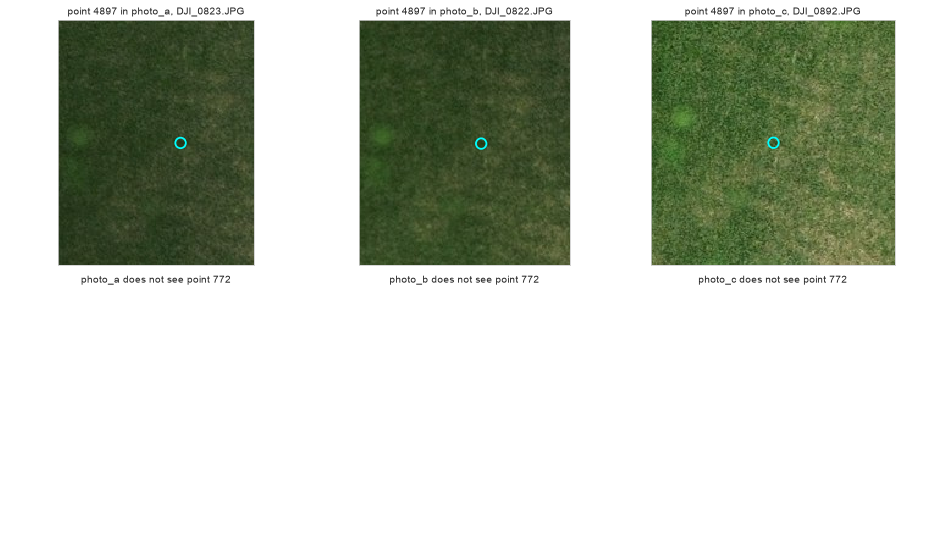

In [8]:
point_ids, observations = np.unique(tracks["point"], return_counts=True)
kit = {letter: names.index(choices["photos"][letter]["name"]) for letter in "abc"}
kit_images = {"a": photo_a, "b": photo_b, "c": np.asarray(Image.open("data/photo_c.jpg"))}
longest = point_ids[np.argmax(observations)]
seen_by = sorted(int(s) for s in tracks["shot"][tracks["point"] == longest])
print(f"the longest track of the flight is point {longest}, seen in {len(seen_by)} photographs: {', '.join(names[s] for s in seen_by)}")
print(f"of the kit's three photographs it is in {', '.join('photo_' + k for k, i in kit.items() if i in seen_by) or 'none'}")
in_kit = np.isin(tracks["shot"], list(kit.values()))                       # the longest track that all three kit photographs observe
ids_kit, counts_kit = np.unique(tracks["point"][in_kit], return_counts=True)
shared = ids_kit[counts_kit == len(kit)]
lengths_shared = observations[np.searchsorted(point_ids, shared)]
shown = shared[np.argmax(lengths_shared)]
print(f"the longest track all three kit photographs see is point {shown}, in {lengths_shared.max()} photographs of the flight")

def crop_at(ax, image, u, v, title, half=100):
    '''A crop of the sample around a feature position, with the position ringed.'''
    r0, c0 = int(max(0, v - half)), int(max(0, u - half))
    crop = image[r0:r0 + 2 * half, c0:c0 + 2 * half]
    ax.imshow(crop, interpolation="nearest", extent=(c0, c0 + crop.shape[1], r0 + crop.shape[0], r0))
    ax.scatter(u, v, s=110, facecolor="none", edgecolor="cyan", linewidth=1.8); ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(13, 7.6))
for row, point in zip(axes, (shown, longest)):
    for ax, (letter, shot) in zip(row, kit.items()):
        record = np.nonzero((tracks["point"] == point) & (tracks["shot"] == shot))[0]
        if len(record) == 0:
            ax.set_axis_off(); ax.set_title(f"photo_{letter} does not see point {point}", fontsize=10); continue
        u, v = feature_pixels(np.column_stack([tracks["x"][record], tracks["y"][record]]), sample_w, sample_h)
        crop_at(ax, kit_images[letter], u[0], v[0], f"point {point} in photo_{letter}, {names[shot]}")
fig.tight_layout()

The first line names the longest track of the flight and lists every photograph that saw it. Look at the names, and at whether they run in sequence or come from different passes over the field, since a track seen from several passes ties the block across them, which is what makes a block rigid rather than a chain. The top row of the picture is the longest track that all three of the kit's photographs see, and the bottom row is the longest track of the flight wherever the kit has the photograph; where it does not, the panel says so. Look at the three crops of the top row. They are the same ground detail seen from three positions, and the ring sits on the same spot in each, which is what a track is, one point on the ground and one feature in every photograph that recorded it. The adjustment of 03b-04 will demand that the rays from those features through their camera centres meet at one point, and a long track gives it many rays to satisfy at once.

## Your turn

The ratio test's threshold is a dial. At a stricter setting fewer candidates pass and more of them should be true, at a looser one more pass and more of them should be false, and what the geometry then keeps says whether the dial mattered. Run the matching and the geometric check again at ratios 0.7 and 0.9 and read the candidates, the inliers and the inlier share at each setting beside the ones at 0.8 above. Then say in a sentence which setting you would give the software and why.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. nearest and ratios hold the nearest neighbour and the ratio of every feature of photo_a, and fundamental_ransac is the check from above.
#
# for threshold in (___, ___):
#     passed_t = ratios < threshold
#     pixels_a_t = np.column_stack(feature_pixels(points_a[passed_t], sample_w, sample_h))
#     pixels_b_t = np.column_stack(feature_pixels(points_b[nearest[passed_t]], sample_w, sample_h))
#     F_t, inliers_t = fundamental_ransac(pixels_a_t, pixels_b_t, iterations=2000, threshold_px=1.0, seed=0)
#     print(f"ratio {threshold}   {passed_t.sum()} candidates, {inliers_t.sum()} inliers, {inliers_t.mean():.1%} kept by the geometry")

## Check your understanding

1. The ratio test compares the nearest descriptor distance with the second nearest rather than with a fixed number. Say what goes wrong with a fixed distance on a mown lawn and on a roof edge, and why the ratio survives both.
2. Define an epipolar line in one sentence. Then say why the lines of a level nadir pair are nearly parallel, and where they would converge if photo_b had been taken from a point on photo_a's own optical axis, lower down.
3. RANSAC fits eight candidates at a time and least squares would fit all of them at once. Explain why the second is wrong here even when nine candidates in ten are true, and what the Sampson distance measures.
4. A track's length is the number of photographs that saw its ground point. Say what a track of length two can and cannot do for the adjustment, why a track longer than the number of photographs is impossible, and what the software does with such a track.

## Where we are

You have matched two photographs by their descriptors and seen the ratio test keep what a fixed distance could not, fitted the fundamental matrix with the eight-point algorithm inside RANSAC and watched the geometry throw out candidates that looked right, and drawn the epipolar lines the dense matching will search along. You have read every pair of the flight the software tried and matched, and joined pairwise matches into tracks with a union find whose lengths sit beside the software's own. Each track is a ground point waiting for its coordinates.

The habit worth keeping: a match is a claim and not a fact, so check every set of matches against a geometric model before you count it, and read what the model threw out as carefully as what it kept.

In 03b-04 the tracks become points in space and the cameras find their places.

## Further resources

Nothing in this course requires anything below.

Lowe's paper of 2004 introduced the descriptor, the ratio test and the argument for it: https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf. Fischler and Bolles introduced random sample consensus in 1981: https://dl.acm.org/doi/10.1145/358669.358692

Hartley and Zisserman, Multiple View Geometry in Computer Vision, second edition, Cambridge University Press 2004, is the standard reference for the fundamental matrix, the normalised eight-point algorithm and the Sampson distance; it has no free edition. Szeliski's Computer Vision: Algorithms and Applications, second edition, is free and covers feature matching in chapter 7 and two-view geometry and structure from motion in chapter 11: https://szeliski.org/Book/

OpenSfM, the structure from motion engine inside OpenDroneMap, documents how it chose candidate pairs, matched them, checked them and built its tracks: https://opensfm.org/docs/. OpenDroneMap's documentation lists the options behind that, the matching neighbours and the feature quality among them: https://docs.opendronemap.org/arguments/

The photographs, the features, the matches, the tracks and the reconstruction are the course's own flight, published under CC BY 4.0.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The two ratio runs, from the files themselves so that the cell stands on its own; the functions are the notebook's, unchanged:

```python
import math
import numpy as np
from PIL import Image

features = np.load("data/features_pair.npz")
sample_w, sample_h = Image.open("data/photo_a.jpg").size
points_a, points_b = features["points_a"], features["points_b"]

def feature_pixels(points, width, height):
    size = max(width, height)
    return points[:, 0] * size + width / 2.0 - 0.5, points[:, 1] * size + height / 2.0 - 0.5

def two_nearest(descriptors_from, descriptors_to, chunk=1000):
    a = np.asarray(descriptors_from, dtype=np.float32); b = np.asarray(descriptors_to, dtype=np.float32)
    bb = (b * b).sum(axis=1)
    nearest, ratios = [], []
    for start in range(0, len(a), chunk):
        part = a[start:start + chunk]
        squared = (part * part).sum(axis=1)[:, None] + bb[None, :] - 2.0 * part @ b.T
        two = np.argpartition(squared, 1, axis=1)[:, :2]
        distances = np.take_along_axis(squared, two, axis=1)
        first = np.argmin(distances, axis=1); rows = np.arange(len(part))
        best, second = distances[rows, first], distances[rows, 1 - first]
        nearest.append(two[rows, first]); ratios.append(np.sqrt(np.maximum(best, 0) / np.maximum(second, 1e-12)))
    return np.concatenate(nearest), np.concatenate(ratios)

def normalise_points(points):
    centre = points.mean(axis=0); scale = math.sqrt(2.0) / np.sqrt(((points - centre) ** 2).sum(axis=1)).mean()
    T = np.array([[scale, 0.0, -scale * centre[0]], [0.0, scale, -scale * centre[1]], [0.0, 0.0, 1.0]])
    return (points - centre) * scale, T

def eight_point(pa, pb):
    na, Ta = normalise_points(pa); nb, Tb = normalise_points(pb)
    A = np.column_stack([nb[:, 0] * na[:, 0], nb[:, 0] * na[:, 1], nb[:, 0], nb[:, 1] * na[:, 0], nb[:, 1] * na[:, 1], nb[:, 1], na[:, 0], na[:, 1], np.ones(len(na))])
    _, _, vt = np.linalg.svd(A)
    F = vt[-1].reshape(3, 3)
    u, s, vt = np.linalg.svd(F); s[2] = 0.0
    F = u @ np.diag(s) @ vt
    F = Tb.T @ F @ Ta
    return F / F[2, 2] if abs(F[2, 2]) > 1e-12 else F

def sampson_distance(F, pa, pb):
    ha = np.column_stack([pa, np.ones(len(pa))]); hb = np.column_stack([pb, np.ones(len(pb))])
    Fa = ha @ F.T; Ftb = hb @ F
    numerator = (hb * Fa).sum(axis=1) ** 2
    denominator = Fa[:, 0] ** 2 + Fa[:, 1] ** 2 + Ftb[:, 0] ** 2 + Ftb[:, 1] ** 2
    return np.sqrt(numerator / np.maximum(denominator, 1e-12))

def fundamental_ransac(pa, pb, iterations=2000, threshold_px=1.0, seed=0):
    rng = np.random.default_rng(seed)
    pa = np.asarray(pa, dtype=float); pb = np.asarray(pb, dtype=float)
    best_mask, best_count = None, -1
    for _ in range(iterations):
        pick = rng.choice(len(pa), 8, replace=False)
        try:
            F = eight_point(pa[pick], pb[pick])
        except np.linalg.LinAlgError:
            continue
        agree = sampson_distance(F, pa, pb) < threshold_px
        if agree.sum() > best_count:
            best_count, best_mask = int(agree.sum()), agree
    F = eight_point(pa[best_mask], pb[best_mask])
    return F, sampson_distance(F, pa, pb) < threshold_px

nearest, ratios = two_nearest(features["descriptors_a"], features["descriptors_b"])
for threshold in (0.7, 0.9):
    passed_t = ratios < threshold
    pixels_a_t = np.column_stack(feature_pixels(points_a[passed_t], sample_w, sample_h))
    pixels_b_t = np.column_stack(feature_pixels(points_b[nearest[passed_t]], sample_w, sample_h))
    F_t, inliers_t = fundamental_ransac(pixels_a_t, pixels_b_t, iterations=2000, threshold_px=1.0, seed=0)
    print(f"ratio {threshold}   {passed_t.sum()} candidates, {inliers_t.sum()} inliers, {inliers_t.mean():.1%} kept by the geometry")
```

Read the three settings as a row, with the run at 0.8 between them. Look at how much the candidate count moves against how much the inlier count moves. Tightening the ratio removes candidates the geometry would mostly have kept anyway, and loosening it admits candidates the geometry then throws out, so the inlier share falls as the ratio rises while the inlier count moves far less; the geometry is the better judge, and the ratio test's job is to keep its workload honest. The software's default of 0.8 sits where that trade is fair.